# Week 1

In [24]:
# 라이브러리 import 및 버전 확인
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow 버전:", tf.__version__)
print("NumPy 버전:", np.__version__)
print("Pandas 버전:", pd.__version__)


# 데이터 다운로드
path_to_train_file = tf.keras.utils.get_file('train.txt',
                                             'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt')


path_to_test_file = tf.keras.utils.get_file('test.txt',
                                            'https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt')

TensorFlow 버전: 2.21.0
NumPy 버전: 2.4.4
Pandas 버전: 3.0.2


In [25]:
train_text = open(path_to_train_file, 'rb').read().decode(encoding='utf-8')
test_text = open(path_to_test_file, 'rb').read().decode(encoding='utf-8')

print(f'train text 길이: {len(train_text)} characters') 
print(f'test text 길이: {len(test_text)} characters')
print('test text의 처음 500자 출력:\n', test_text[:500]) 

train text 길이: 6937271 characters
test text 길이: 2318260 characters
test text의 처음 500자 출력:
 id	document	label
6270596	굳 ㅋ	1
9274899	GDNTOPCLASSINTHECLUB	0
8544678	뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아	0
6825595	지루하지는 않은데 완전 막장임... 돈주고 보기에는....	0
6723715	3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??	0
7898805	음악이 주가 된, 최고의 음악영화	1
6315043	진정한 쓰레기	0
6097171	마치 미국애니에서 튀어나온듯한 창의력없는 로봇디자인부터가,고개를 젖게한다	0
8932678	갈수록 개판되가는 중국영화 유치하고 내용없음 폼잡다 끝남 말도안되는 무기에 유치한cg남무 아 그립다 동사서독같은 영화가 이건 3류아류작이다	0
6242223	이별의 아픔뒤에 찾아오는 새로운 인연의 기쁨 But, 모든 사람이 그렇지는 않네..	1
7462111	괜찮네요오랜만포켓몬스터잼밌어요	1
8425305	한국독립영화의


In [26]:
#  Y(정답 라벨) 데이터 만들기
train_Y = np.array([
    [int(row.split('\t')[2])] # 3. 라벨 값 추출
    for row in train_text.split('\n')[1:] # 1. 첫 번째 줄(0) 제외, 한 줄씩 순회
    if row.count('\t') > 0 # 2. 탭 없는 줄 제외
])

test_Y = np.array([
    [int(row.split('\t')[2])]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
])

print("train_Y shape:", train_Y.shape)
print("test_Y shape:", test_Y.shape)
print("train_Y sample:", train_Y[:10])

train_Y shape: (150000, 1)
test_Y shape: (50000, 1)
train_Y sample: [[0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [0]
 [0]
 [1]
 [1]]


In [27]:
import re

def clean_str(string): 
    string = re.sub(r"[^가-힣A-Za-z0-9(),!?\'\`]", " ", string) # 한글, 영어, 숫자, 일부 특수문자 제외한 모든 문자 제거
    string = re.sub(r"\'s", " \'s", string) # 
    string = re.sub(r"\'ve", " \'ve", string) 
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string) 
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    string = re.sub(r"\'{2,}", "\'", string)
    string = re.sub(r"\'", "", string)

    return string.lower()

# 리뷰 텍스트만 추출 
train_text_X = [row.split('\t')[1] 
                for row in train_text.split('\n')[1:] 
                if row.count('\t') > 0]

#clean_str을 이용해 리뷰 텍스트 전처리
train_text_X = [clean_str(sentence) for sentence in train_text_X]

# 문장을 띄어쓰기 단위로 단어 분리
sentences = [sentence.split(' ') for sentence in train_text_X]


# 학습 데이터 10개 샘플 출력
for i in range(10):
    print(sentences[i])

['아', '더빙', '진짜', '짜증나네요', '목소리']
['흠', '포스터보고', '초딩영화줄', '오버연기조차', '가볍지', '않구나']
['너무재밓었다그래서보는것을추천한다']
['교도소', '이야기구먼', '솔직히', '재미는', '없다', '평점', '조정']
['사이몬페그의', '익살스런', '연기가', '돋보였던', '영화', '!', '스파이더맨에서', '늙어보이기만', '했던', '커스틴', '던스트가', '너무나도', '이뻐보였다']
['막', '걸음마', '뗀', '3세부터', '초등학교', '1학년생인', '8살용영화', '별반개도', '아까움', '']
['원작의', '긴장감을', '제대로', '살려내지못했다', '']
['별', '반개도', '아깝다', '욕나온다', '이응경', '길용우', '연기생활이몇년인지', '정말', '발로해도', '그것보단', '낫겟다', '납치', '감금만반복반복', '이드라마는', '가족도없다', '연기못하는사람만모엿네']
['액션이', '없는데도', '재미', '있는', '몇안되는', '영화']
['왜케', '평점이', '낮은건데', '\\?', '꽤', '볼만한데', '헐리우드식', '화려함에만', '너무', '길들여져', '있나', '\\?', '']


In [28]:
VOCAB_SIZE = 2000   # 단어 사전 크기
MAX_LEN = 25        # 최대 문장 길이 (패딩 기준)

#전처리 담당 레이어 정의
vectorize_layer = tf.keras.layers.TextVectorization(
    standardize='lower_and_strip_punctuation',  # 소문자 변환 + 구두점 제거
    split='whitespace',                         # 띄어쓰기 기준 토큰화
    max_tokens=VOCAB_SIZE,                      # 단어 사전 크기
    output_mode='int',                          # 정수 인코딩
    output_sequence_length=MAX_LEN              # 자동 패딩
)

# 텍스트로 단어 사전 구축 (단어:정수 매핑)
vectorize_layer.adapt(train_text_X)

# 단어 사전을 이용해 텍스트 데이터를 정수 시퀀스로 변환
train_X = vectorize_layer(train_text_X)

print(train_X[0])

print(train_X[:5])

tf.Tensor(
[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0], shape=(25,), dtype=int64)
tf.Tensor(
[[  23  902    5    1 1097    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [ 586    1    1    1    1    1    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1   68  345   28   33    1    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0]
 [   1    1  102    1    2    1    1  844    1    1  570    1    0    0
     0    0    0    0    0    0    0    0    0    0    0]], shape=(5, 25), dtype=int64)


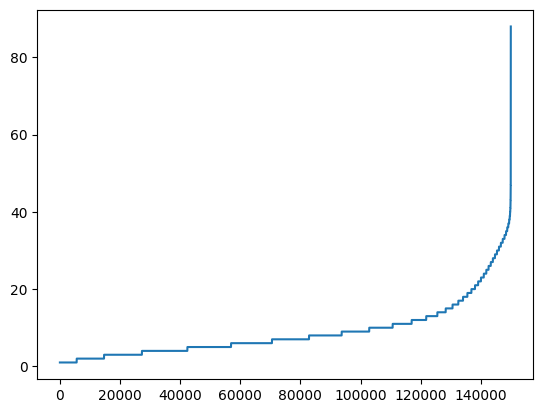

In [29]:
import matplotlib.pyplot as plt
sentence_len = [len(sentence) for sentence in sentences] # 각 문장의 단어 수 계산
sentence_len.sort() # 단어 수 기준 정렬
plt.plot(sentence_len)
plt.show()

In [30]:
print(sum([int(l<=25) for l in sentence_len]))

142587


# week 2

In [31]:
test_text_X = [
    row.split('\t')[1]
    for row in test_text.split('\n')[1:]
    if row.count('\t') > 0
]

# Week1에서 학습된 vectorize_layer 그대로 사용합니다.
test_X = vectorize_layer(test_text_X)

print("test_X shape:", test_X.shape)
print("test_Y shape:", test_Y.shape)

test_X shape: (50000, 25)
test_Y shape: (50000, 1)


In [32]:
# 하이퍼파라미터 설정
VOCAB_SIZE = 2000
EMBEDDING_DIM = 128
MAX_LEN = 25
EPOCHS = 10
BATCH_SIZE = 32

# model 정의 
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)), #입력층
    tf.keras.layers.GlobalAveragePooling1D(), #은닉층
    tf.keras.layers.Dense(64, activation='relu'), #은닉층
    tf.keras.layers.Dense(1, activation='sigmoid') #출력층
])
model.summary()

#현재 가중치 확인
model.get_weights()  


/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

[array([[-0.02985241, -0.03654095, -0.0293412 , ..., -0.01020171,
         -0.04156021,  0.03271767],
        [ 0.00611218,  0.01826474,  0.04044104, ..., -0.01139494,
          0.04594866, -0.03355037],
        [ 0.01760772, -0.00287315,  0.01029197, ...,  0.02788423,
          0.04900796,  0.01467228],
        ...,
        [ 0.0114759 , -0.0441516 , -0.03186703, ...,  0.02392453,
          0.01821916,  0.00792615],
        [-0.00328543, -0.04395585, -0.01885562, ...,  0.02438066,
         -0.00382482,  0.00169001],
        [-0.01344591,  0.00405423,  0.01592969, ..., -0.01462384,
          0.03441873, -0.00615595]], shape=(2000, 128), dtype=float32),
 array([[-0.14659213,  0.16930436,  0.10695641, ...,  0.126557  ,
          0.1327024 ,  0.15339585],
        [ 0.02355205, -0.13872615, -0.074896  , ..., -0.11284763,
          0.01586403, -0.1447965 ],
        [-0.08610125, -0.14992645,  0.07539202, ..., -0.12793212,
         -0.09352323, -0.14689972],
        ...,
        [-0.13207929

In [33]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 모델 학습
history = model.fit(
    train_X, train_Y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

model.summary()
model.get_weights()  


Epoch 1/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7221 - loss: 0.5082 - val_accuracy: 0.7584 - val_loss: 0.4612
Epoch 2/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7494 - loss: 0.4647 - val_accuracy: 0.7583 - val_loss: 0.4596
Epoch 3/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7540 - loss: 0.4573 - val_accuracy: 0.7558 - val_loss: 0.4597
Epoch 4/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7547 - loss: 0.4533 - val_accuracy: 0.7580 - val_loss: 0.4625
Epoch 5/10
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7578 - loss: 0.4484 - val_accuracy: 0.7569 - val_loss: 0.4588
Epoch 6/10
 630/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7537 - loss: 0.4468

KeyboardInterrupt: 

In [34]:
test_loss, test_acc = model.evaluate(test_X, test_Y, verbose=0)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

Test Loss: 0.4776, Test Accuracy: 0.7406


In [35]:
example_sentences = [
    "이 영화 진짜 재밌다!",
    "완전 지루함. 비추",
    "배우 연기는 좋았지만 스토리가 아쉬움"
]

example_seq = vectorize_layer(example_sentences)
pred = model.predict(example_seq)

for s, p in zip(example_sentences, pred):
    print(f"문장: {s}")
    print(f"긍정 확률: {p[0]:.4f}")
    print("결과:", "긍정 😊" if p[0] > 0.5 else "부정 😞")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
문장: 이 영화 진짜 재밌다!
긍정 확률: 0.9694
결과: 긍정 😊
문장: 완전 지루함. 비추
긍정 확률: 0.0042
결과: 부정 😞
문장: 배우 연기는 좋았지만 스토리가 아쉬움
긍정 확률: 0.0443
결과: 부정 😞


## Misson 2: EPOCHS = 10 vs EPOCHS = 30

In [ ]:
# 하이퍼파라미터 설정
VOCAB_SIZE = 2000
EMBEDDING_DIM = 128
MAX_LEN = 25
EPOCHS_30 = 30 # 30번 학습
BATCH_SIZE = 32

# model_1 정의 
model_1 = tf.keras.Sequential([
    tf.keras.layers.Embedding(VOCAB_SIZE, EMBEDDING_DIM, input_shape=(MAX_LEN,)), #입력층
    tf.keras.layers.GlobalAveragePooling1D(), #은닉층
    tf.keras.layers.Dense(64, activation='relu'), #은닉층
    tf.keras.layers.Dense(1, activation='sigmoid') #출력층
])

model_1.summary()

/opt/miniconda3/envs/gdg/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 128)        │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,321 (1.01 MB)

 Trainable params: 264,321 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# model_1 학습
history_30 = model_1.fit(
    train_X, train_Y,
    epochs=EPOCHS_30, #30번
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 932us/step - accuracy: 0.7216 - loss: 0.5090 - val_accuracy: 0.7582 - val_loss: 0.4593
Epoch 2/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 974us/step - accuracy: 0.7517 - loss: 0.4635 - val_accuracy: 0.7622 - val_loss: 0.4551
Epoch 3/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 905us/step - accuracy: 0.7535 - loss: 0.4577 - val_accuracy: 0.7461 - val_loss: 0.4670
Epoch 4/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 906us/step - accuracy: 0.7545 - loss: 0.4532 - val_accuracy: 0.7530 - val_loss: 0.4652
Epoch 5/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 4s 933us/step - accuracy: 0.7564 - loss: 0.4494 - val_accuracy: 0.7610 - val_loss: 0.4549
Epoch 6/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 902us/step - accuracy: 0.7586 - loss: 0.4458 - val_accuracy: 0.7582 - val_loss: 0.4584
Epoch 7/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 909us/step - accuracy: 0.7593 - loss: 0.4426 - val_accuracy: 0.7540 - val_loss: 0.4596
Epoch 8/30
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 3s 923us/step - accuracy: 0.7637 - loss: 0.43

### (epoch = 10) 손실 곡선 & 정확도 변화 시각화

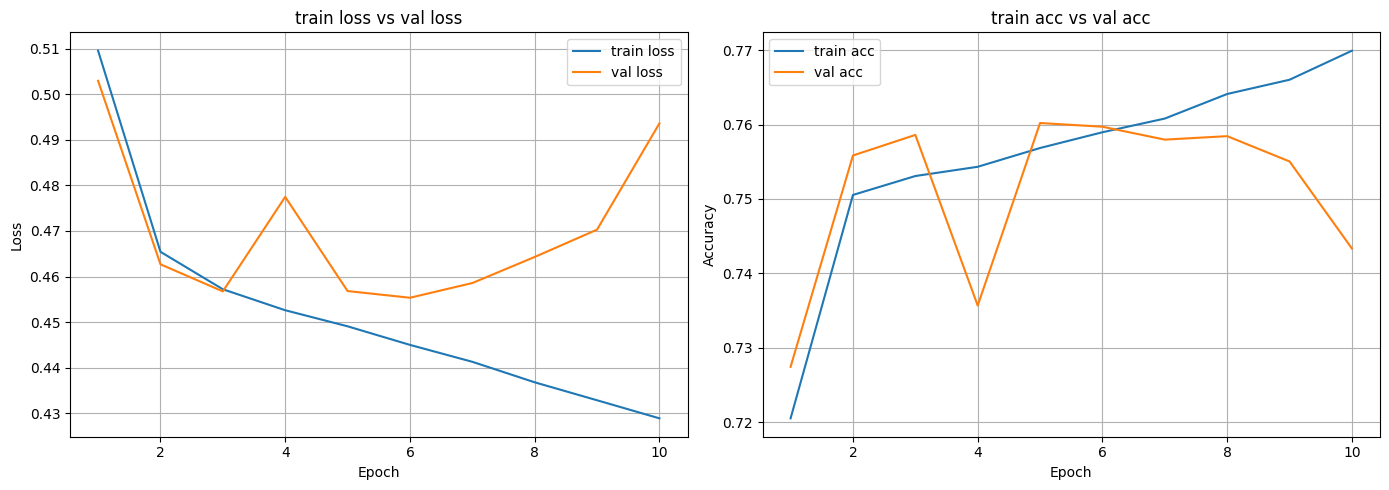

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history.history['loss'], label='train loss')
ax1.plot(epochs_range, history.history['val_loss'], label='val loss')
ax1.set_title('train loss vs val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history.history['accuracy'], label='train acc')
ax2.plot(epochs_range, history.history['val_accuracy'], label='val acc')
ax2.set_title('train acc vs val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)


plt.tight_layout()
plt.show()

### (epoch = 30) 손실 곡선 & 정확도 변화 시각화

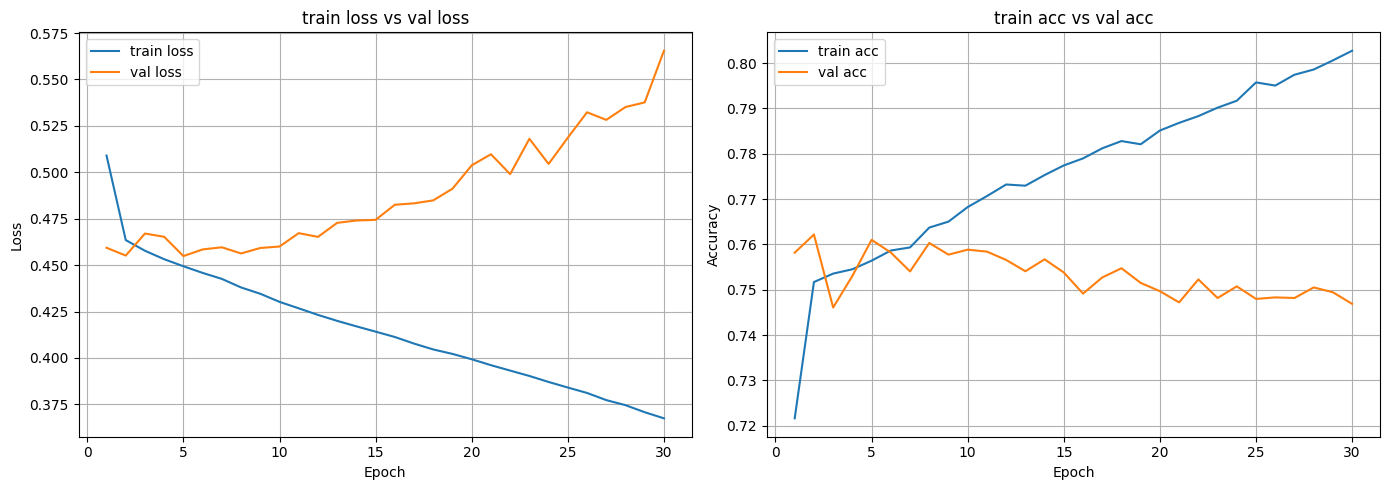

In [ ]:
epochs_range = range(1, EPOCHS_30 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, history_30.history['loss'], label='train loss')
ax1.plot(epochs_range, history_30.history['val_loss'], label='val loss')
ax1.set_title('train loss vs val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history_30.history['accuracy'], label='train acc')
ax2.plot(epochs_range, history_30.history['val_accuracy'], label='val acc')
ax2.set_title('train acc vs val acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)


plt.tight_layout()
plt.show()

그래프 해석: epoch 5 근처에서 val_loss가 약 0.45로 최저점을 찍고, 이후론 계속 증가. 이는 과적합이 발생한 것임. 

원인 1. 에폭수 과다 => val_loss 최저점일때 학습을 조기 종료해야 함(EarlyStopping) 

원인 2. 정규화 없음 => 각 뉴런이 훈련 데이터에 과도하게 특화되지 않도록 Dropout 레이어 추가 

원인 3. VOCAB_SIZE 작음 => 15만개의 리뷰 중 단어 2000개만 사용해, 대부분의 단어가 unk 토큰이 됨. 모델은 unknown 토큰의 패턴을 외우는 방향으로 학습하게 됨.


